# EDA — Roboflow Vehicle Body Style Dataset (Tuần 5, phân loại phương tiện)

Dataset này để bổ sung cho nhánh phân loại kiểu dáng xe con (sedan/SUV/hatchback/MPV/pickup/...), vì dữ liệu biển số/bối cảnh VN (Tuần 2) chỉ có 1 lớp "Car" gộp chung, không tách kiểu dáng.

| Mục | Nội dung |
|---|---|
| Nguồn | [universe.roboflow.com/research-projects-qodgb/vehicle-body-style-dataset](https://universe.roboflow.com/research-projects-qodgb/vehicle-body-style-dataset) |
| License | CC BY 4.0 |
| Số ảnh | 10.000 (7.014 train / 1.999 valid / 987 test) |
| Classes | 12 kiểu dáng (theo taxonomy CompCars): Convertible, Crossover, Fastback, Hardtop Convertible, Hatchback, MPV, Minibus, Pickup Truck, SUV, Sedan, Sports, Wagon |
| Format | YOLOv8 detection (bounding box) |

Quá trình so sánh 12 dataset phân loại phương tiện đã khảo sát ghi ở `docs/research/2026-07-30-vehicle-classification-datasets.md`. Hai câu hỏi cần EDA mới trả lời được (mô tả text không nói): dataset có mất cân bằng lớp không, và ảnh có khác nhiều so với xe phổ biến ở VN không (xe Mỹ/châu Âu/Trung Quốc so với Toyota Vios, Honda City, Kia Morning...).

Chạy local, không cần GPU. Cần venv `.venv/` (repo root), `requirements-eda.txt`, `.env` có `ROBOFLOW_API_KEY`.


In [1]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

random.seed(42)
np.random.seed(42)

REPO_ROOT = Path.cwd().resolve().parents[2] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_RAW = REPO_ROOT / "data" / "raw"
FIG_DIR = REPO_ROOT / "docs" / "report" / "figures"
OUT_DIR = REPO_ROOT / "docs" / "research" / "eda_outputs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(REPO_ROOT / ".env")
print("Repo root:", REPO_ROOT)


Repo root: E:\Learn\UIT\UIT2026-DoAnCuoiKi


## 1. Tải dữ liệu

Có rồi thì bỏ qua, không tải lại.

In [2]:
from roboflow import Roboflow

DATASET_DIR = DATA_RAW / "vehicle_body_style"
if DATASET_DIR.exists():
    print("Da ton tai, bo qua tai lai:", DATASET_DIR)
else:
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace("research-projects-qodgb").project("vehicle-body-style-dataset")
    project.version(3).download("yolov8", location=str(DATASET_DIR))


Da ton tai, bo qua tai lai: E:\Learn\UIT\UIT2026-DoAnCuoiKi\data\raw\vehicle_body_style


## 2. Hàm tiện ích (dùng lại pattern từ EDA biển số)

In [3]:
SPLITS = ["train", "valid", "test"]
CLASS_NAMES = ["Convertible", "Crossover", "Fastback", "Hardtop Convertible", "Hatchback",
               "MPV", "Minibus", "Pickup Truck", "SUV", "Sedan", "Sports", "Wagon"]


def image_label_pairs():
    pairs = []
    for split in SPLITS:
        img_dir = DATASET_DIR / split / "images"
        lbl_dir = DATASET_DIR / split / "labels"
        if not img_dir.exists():
            continue
        for img_path in img_dir.iterdir():
            if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png"):
                continue
            lbl_path = lbl_dir / (img_path.stem + ".txt")
            pairs.append((split, img_path, lbl_path if lbl_path.exists() else None))
    return pairs


def parse_label_file(path):
    """YOLO bbox format: class xc yc w h (normalized). Returns list of (class_id, area_ratio)."""
    rows = []
    if path is None:
        return rows
    text = path.read_text(encoding="utf-8", errors="ignore")
    for line in text.splitlines():
        parts = line.strip().split()
        if not parts or not parts[0].lstrip("-").isdigit():
            continue
        cls = int(parts[0])
        vals = list(map(float, parts[1:]))
        if len(vals) >= 4:
            rows.append((cls, vals[2] * vals[3]))
    return rows


ALL_PAIRS = image_label_pairs()
print(f"Tong so anh: {len(ALL_PAIRS)}")


Tong so anh: 10000


## 3. Số lượng ảnh theo split

In [4]:
split_df = pd.DataFrame([{"split": s} for s, _, _ in ALL_PAIRS])
split_counts = split_df.value_counts("split")
split_counts


split
train    7014
valid    1999
test      987
Name: count, dtype: int64

## 4. Phân bố class (12 kiểu dáng)

In [5]:
class_rows = []
for split, img_path, lbl_path in ALL_PAIRS:
    for cls, area in parse_label_file(lbl_path):
        class_rows.append({"split": split, "class_id": cls, "class_name": CLASS_NAMES[cls], "box_area_ratio": area})
class_df = pd.DataFrame(class_rows)

class_counts = class_df["class_name"].value_counts()
class_counts


class_name
Wagon                  844
MPV                    844
Hatchback              837
Sedan                  835
Pickup Truck           834
Sports                 834
Minibus                832
Fastback               830
SUV                    829
Convertible            829
Hardtop Convertible    828
Crossover              824
Name: count, dtype: int64

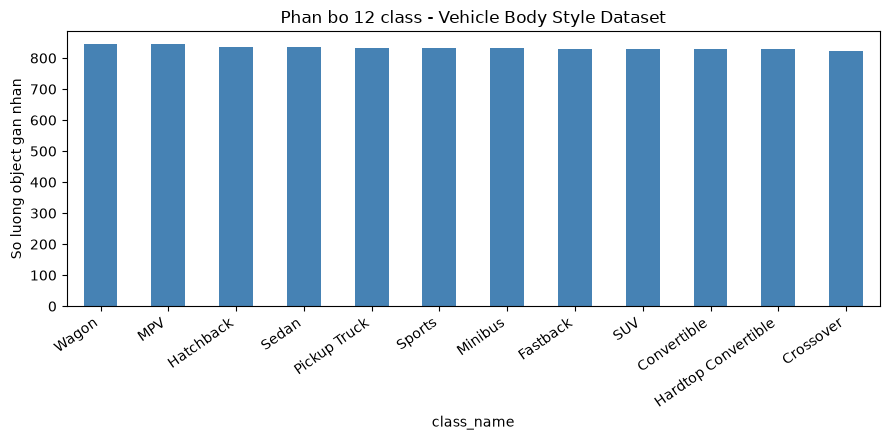

Ty le mat can bang (max/min class count): 1.0x
Class nhieu nhat: Wagon (844)
Class it nhat: Crossover (824)


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
class_counts.sort_values(ascending=False).plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("So luong object gan nhan")
ax.set_title("Phan bo 12 class - Vehicle Body Style Dataset")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_vbs_class_distribution.png", dpi=150)
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Ty le mat can bang (max/min class count): {imbalance_ratio:.1f}x")
print(f"Class nhieu nhat: {class_counts.idxmax()} ({class_counts.max()})")
print(f"Class it nhat: {class_counts.idxmin()} ({class_counts.min()})")


## 5. Kích thước ảnh, tỉ lệ khung hình & độ sáng (mẫu ngẫu nhiên)

In [7]:
SAMPLE_N = 800
sample_pairs = random.sample(ALL_PAIRS, min(SAMPLE_N, len(ALL_PAIRS)))
pixel_rows = []
for split, img_path, lbl_path in sample_pairs:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    pixel_rows.append({
        "split": split, "width": w, "height": h, "aspect_ratio": w / h,
        "mean_brightness": float(gray.mean()), "std_brightness": float(gray.std()),
    })
pixel_df = pd.DataFrame(pixel_rows)
pixel_df[["width", "height", "aspect_ratio", "mean_brightness"]].describe()


,width,height,aspect_ratio,mean_brightness
count,800.0,800.0,800.0,800.000000
mean,320.0,320.0,1.0,83.437806
std,0.0,0.0,0.0,19.708246
min,320.0,320.0,1.0,5.018350
25%,320.0,320.0,1.0,70.945776
50%,320.0,320.0,1.0,83.405796
75%,320.0,320.0,1.0,95.980520
max,320.0,320.0,1.0,149.410742


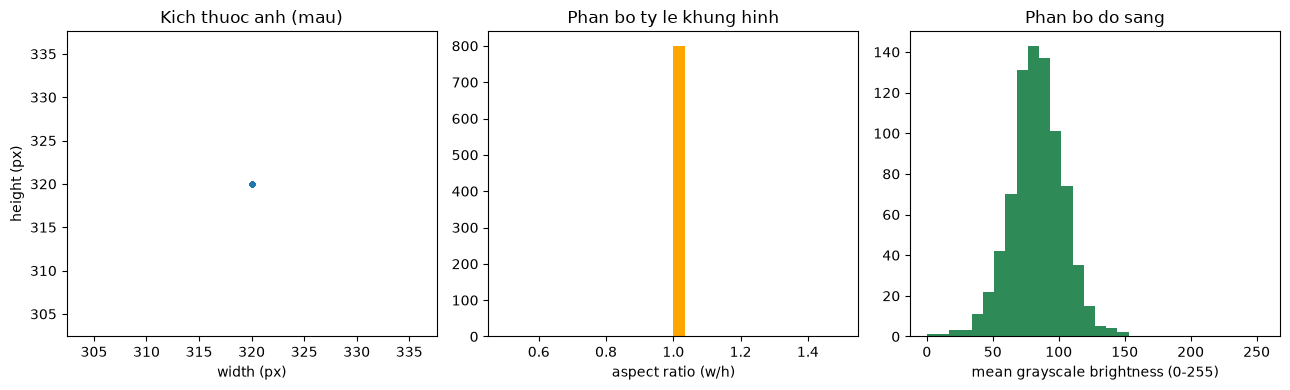

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(pixel_df["width"], pixel_df["height"], s=8, alpha=0.4)
axes[0].set_xlabel("width (px)"); axes[0].set_ylabel("height (px)")
axes[0].set_title("Kich thuoc anh (mau)")

axes[1].hist(pixel_df["aspect_ratio"], bins=30, color="orange")
axes[1].set_xlabel("aspect ratio (w/h)")
axes[1].set_title("Phan bo ty le khung hinh")

axes[2].hist(pixel_df["mean_brightness"], bins=30, range=(0, 255), color="seagreen")
axes[2].set_xlabel("mean grayscale brightness (0-255)")
axes[2].set_title("Phan bo do sang")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_vbs_size_brightness.png", dpi=150)
plt.show()


## 6. Diện tích xe tương đối trong khung hình (bbox area ratio)

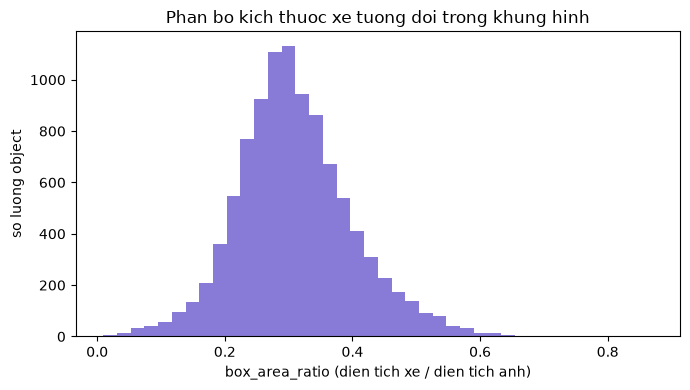

count    10000.000000
mean         0.309654
std          0.090498
min          0.009229
25%          0.252065
50%          0.302305
75%          0.361406
max          0.870234
Name: box_area_ratio, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(class_df["box_area_ratio"], bins=40, color="slateblue", alpha=0.8)
ax.set_xlabel("box_area_ratio (dien tich xe / dien tich anh)")
ax.set_ylabel("so luong object")
ax.set_title("Phan bo kich thuoc xe tuong doi trong khung hinh")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_vbs_area_ratio.png", dpi=150)
plt.show()

class_df["box_area_ratio"].describe()


## 7. Xem ảnh mẫu để kiểm tra domain gap (xe quốc tế vs xe phổ biến ở VN)

Đây là câu hỏi quan trọng nhất theo phần gap analysis lúc khảo sát nguồn: dataset này dựa trên taxonomy CompCars nên chủ yếu là xe Mỹ/châu Âu/Trung Quốc — cần xem ảnh mẫu từng class mới biết nó khác xe phổ biến ở VN đến mức nào.

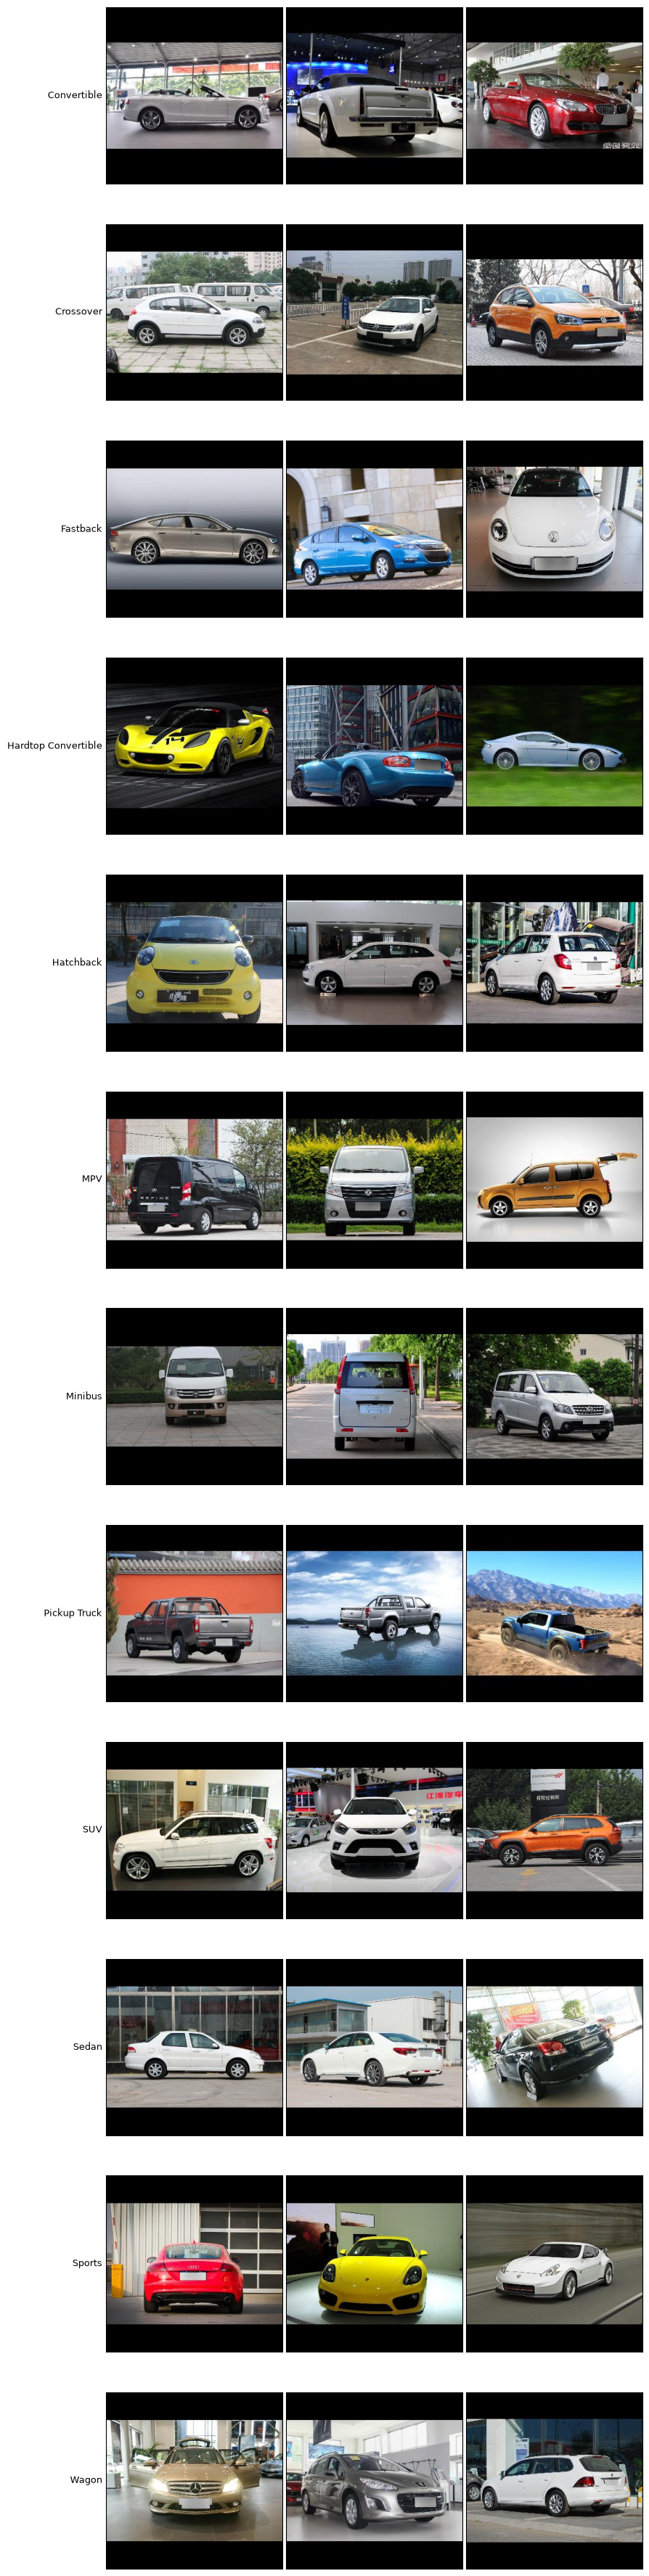

In [10]:
n_show_classes = 12
fig, axes = plt.subplots(n_show_classes, 3, figsize=(9, 3 * n_show_classes))
for row, cname in enumerate(CLASS_NAMES):
    candidates = [(s, p, l) for s, p, l in ALL_PAIRS
                  for cls, _ in (parse_label_file(l) or [])
                  if CLASS_NAMES[cls] == cname]
    # dedupe by image path (one image can have >1 object of same class)
    seen = {}
    for s, p, l in candidates:
        seen[p] = (s, p, l)
    candidates = list(seen.values())
    sample = random.sample(candidates, min(3, len(candidates))) if candidates else []
    for col in range(3):
        ax = axes[row, col]
        if col < len(sample):
            _, img_path, _ = sample[col]
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        if col == 0:
            ax.set_ylabel(cname, fontsize=9, rotation=0, ha="right", va="center")
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_vbs_sample_by_class.png", dpi=130)
plt.show()


## 8. Bảng tổng hợp EDA

In [11]:
summary = {
    "dataset": "vehicle_body_style",
    "label": "Roboflow Vehicle Body Style Dataset",
    "license": "CC BY 4.0",
    "n_images": len(ALL_PAIRS),
    "n_classes": len(CLASS_NAMES),
    "n_objects_labeled": len(class_df),
    "class_imbalance_max_over_min": round(imbalance_ratio, 2),
    "resolution_range": f"{pixel_df['width'].min()}-{pixel_df['width'].max()} x {pixel_df['height'].min()}-{pixel_df['height'].max()}",
    "mean_brightness": round(pixel_df["mean_brightness"].mean(), 1),
    "mean_box_area_ratio": round(class_df["box_area_ratio"].mean(), 4),
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUT_DIR / "eda_vehicle_body_style_summary.csv", index=False)
summary_df


,dataset,label,license,n_images,n_classes,n_objects_labeled,class_imbalance_max_over_min,resolution_range,mean_brightness,mean_box_area_ratio
0,vehicle_body_style,Roboflow Vehicle Body Style Dataset,CC BY 4.0,10000,12,10000,1.02,320-320 x 320-320,83.4,0.3097


## 9. Nhận xét

- 12 class khá cân bằng (824–844 ảnh/class, chênh lệch chỉ 1,02 lần) — không cần lo xử lý mất cân bằng lớp khi dùng bộ này.
- Ảnh bị Roboflow resize về đúng 320×320 khi export, giống tình trạng đã gặp ở A3/A4 (school-fuhih/HaUI) bên dataset biển số — độ phân giải gốc không còn. (Lưu ý: không phải dataset Roboflow nào cũng vậy — A2 bên biển số, ví dụ, không bị resize.)
- Xem ảnh mẫu ở mục 7 thì thấy rõ domain gap: phần lớn ảnh là bối cảnh Trung Quốc (biển hiệu chữ Hán, ảnh chụp tại showroom/auto-show), không có ảnh nào nhận ra là VN. Đúng như lo ngại lúc khảo sát nguồn (dataset dựa theo CompCars, thu thập ở Trung Quốc).
- 3 class Convertible, Sports, Hardtop Convertible gần như toàn xe thể thao/mui trần hạng sang (kiểu Porsche, Lotus) — thực tế bãi xe VN gần như không gặp mấy loại này, có thể cân nhắc gộp lại hoặc bỏ khi train.
- box_area_ratio trung bình 0,31 (xe chiếm khoảng 30% khung hình) — cao hơn nhiều so với ảnh camera cổng bãi xe thật (chỉ 3-4% ở dataset biển số), vì đây là ảnh kiểu chụp quảng cáo/dealer chứ không phải camera giám sát.
